In [1]:
import pandas as pd
import numpy as np

In [127]:
#!pip install pandas openpyxl


In [2]:
df=pd.read_excel('gwl_file.xlsx')

In [3]:
df.shape

(39530, 236)

In [4]:
df.rename(columns={
    "Column13": "year",
    "HISTO_10": "Tree_cover",
    "HISTO_20": "Shrubland",
     "HISTO_30": "Grassland",
     "HISTO_40": "Cropland",
     "HISTO_50": "Built_up",
     "HISTO_60": "sparse_vegetation",
     "HISTO_80": "permenant_water_bodies",
    
}, inplace=True)

In [5]:
print(df.columns.tolist())


['year', 'sin_date', 'cos_date', 'cos_month', 'sin_month', 'Column3', 'GWl_dependent', 'Column10', 'Column11', 'Column14', 'Column15', 'wellDepth', 'Value_atm_pre', 'Value_Evp', 'Value_Rain', 'Value_Temp', 'Value_Sm1', 'Value_Sm2', 'Value_Sm3', 'Value_Sm4', 'Column16', 'Column17', 'Column18', 'Column19', 'avg_househ', 'total_population_count', 'tapwater_t', 'tapwater_u', 'Column2', 'Column4', 'Column5', 'Column6', 'Column7', 'Column8', 'permanent_', 'current_fa', 'area_irrig', 'canals_are', 'wells_tube', 'tanks_lake', 'waterfall_', 'Column22', 'shape_area', 'Column20', 'Column21', 'latitude.1', 'longitude.1', 'wellDepth.1', 'Rainfall (mm)_2023', 'Rainfall (mm)_2024', 'Rainfall (mm)_2025', 'Recharge Worthy Area (ha)_2023_2024_2025', 'Rainfall Recharge_2023', 'Rainfall Recharge_2024', 'Rainfall Recharge_2025', 'Ground Water Irrigation_2023', 'Ground Water Irrigation_2024', 'Ground Water Irrigation_2025', 'Tanks and Ponds_2023', 'Tanks and Ponds_2024', 'Tanks and Ponds_2025', 'Water Conse

In [6]:
df.head()

,year,sin_date,cos_date,cos_month,sin_month,Column3,GWl_dependent,Column10,Column11,Column14,...,South Delhi Municipal Corporation6,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT
0,0,0.97953,0.201299,0.5,-0.866025,NaN,10.688000,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,0,0.97953,0.201299,0.5,-0.866025,NaN,8.012250,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,0,0.97953,0.201299,0.5,-0.866025,NaN,3.466294,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,0,0.97953,0.201299,0.5,-0.866025,NaN,2.613250,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,0,0.97953,0.201299,0.5,-0.866025,NaN,1.258500,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [108]:
df['year'].value_counts()

year
2.0    21594
1.0    12508
0.0     5428
Name: count, dtype: int64

In [7]:
nan_columns = df.columns[df.isnull().all()].tolist()
print(nan_columns)


['Column3', 'Column10', 'Column11', 'Column14', 'Column15', 'Column16', 'Column17', 'Column18', 'Column19', 'Column2', 'Column4', 'Column5', 'Column6', 'Column7', 'Column8', 'Column22', 'Column20', 'Column21', 'Major Parameter Present_QUALITY_2023_2024_2025']


In [8]:
df.drop(nan_columns, axis=1, inplace=True)


In [131]:
print(len(nan_columns))

19


In [9]:
df.shape

(39530, 217)

In [10]:
df.head()

,year,sin_date,cos_date,cos_month,sin_month,GWl_dependent,wellDepth,Value_atm_pre,Value_Evp,Value_Rain,...,South Delhi Municipal Corporation6,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT
0,0,0.97953,0.201299,0.5,-0.866025,10.688000,40.0,98111.257812,-0.002579,1.818651e-07,...,0,0,0,0,0,0,0,0,0,0
1,0,0.97953,0.201299,0.5,-0.866025,8.012250,64.0,98093.382812,-0.002560,1.818651e-07,...,0,0,0,0,0,0,0,0,0,0
2,0,0.97953,0.201299,0.5,-0.866025,3.466294,46.0,98102.007812,-0.002305,1.818651e-07,...,0,0,0,0,0,0,0,0,0,0
3,0,0.97953,0.201299,0.5,-0.866025,2.613250,56.0,98102.007812,-0.002305,1.818651e-07,...,0,0,0,0,0,0,0,0,0,0
4,0,0.97953,0.201299,0.5,-0.866025,1.258500,38.0,98169.679688,-0.002199,1.818651e-07,...,0,0,0,0,0,0,0,0,0,0


In [126]:
df['GWl_dependent'].describe()


count    39530.000000
mean        -1.857725
std         15.135844
min        -48.802750
25%         -8.828125
50%         -2.298500
75%          6.467364
max         47.089500
Name: GWl_dependent, dtype: float64

In [12]:
sand_cols = [
    'sand_0-5cm_mean', 'sand_5-15cm_mean', 'sand_15-30cm_mean', 'sand_30-60cm_mean',
    'sand_60-100cm_mean', 'sand_100-200cm_mean', 'silt_0-5cm_mean', 'silt_5-15cm_mean', 
    'silt_15-30cm_mean', 'silt_30-60cm_mean', 'silt_60-100cm_mean', 'silt_100-200cm_mean', 
    'clay_0-5cm_mean', 'clay_5-15cm_mean', 'clay_15-30cm_mean', 'clay_30-60cm_mean', 
    'clay_60-100cm_mean', 'clay_100-200cm_mean', 'ocd_0-5cm_mean', 'ocd_5-15cm_mean', 
    'ocd_15-30cm_mean', 'ocd_30-60cm_mean', 'ocd_60-100cm_mean', 'ocd_100-200cm_mean', 
    'phh2o_0-5cm_mean', 'phh2o_5-15cm_mean', 'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean',
    'phh2o_60-100cm_mean', 'phh2o_100-200cm_mean', 'bdod_0-5cm_mean', 'bdod_5-15cm_mean',
    'bdod_15-30cm_mean', 'bdod_30-60cm_mean', 'bdod_60-100cm_mean', 'bdod_100-200cm_mean',
    'cec_0-5cm_mean', 'cec_5-15cm_mean', 'cec_15-30cm_mean', 'cec_30-60cm_mean', 'cec_60-100cm_mean', 
    'cec_100-200cm_mean', 'cfvo_0-5cm_mean', 'cfvo_5-15cm_mean', 'cfvo_15-30cm_mean', 'cfvo_30-60cm_mean', 
    'cfvo_60-100cm_mean', 'cfvo_100-200cm_mean', 'nitrogen_0-5cm_mean', 'nitrogen_5-15cm_mean', 'nitrogen_15-30cm_mean',
    'nitrogen_30-60cm_mean', 'nitrogen_60-100cm_mean', 'nitrogen_100-200cm_mean', 'soc_0-5cm_mean', 'soc_5-15cm_mean',
    'soc_15-30cm_mean', 'soc_30-60cm_mean', 'soc_60-100cm_mean', 'soc_100-200cm_mean'
]


df[sand_cols] = df[sand_cols].apply(pd.to_numeric, errors='coerce')


df['sand_mean'] = df[sand_cols].mean(axis=1)


In [132]:
len(sand_cols)

60

In [13]:
df.head()

,year,sin_date,cos_date,cos_month,sin_month,GWl_dependent,wellDepth,Value_atm_pre,Value_Evp,Value_Rain,...,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean
0,0,0.97953,0.201299,0.5,-0.866025,10.688000,40.0,98111.257812,-0.002579,1.818651e-07,...,0,0,0,0,0,0,0,0,0,162.152542
1,0,0.97953,0.201299,0.5,-0.866025,8.012250,64.0,98093.382812,-0.002560,1.818651e-07,...,0,0,0,0,0,0,0,0,0,-32768.000000
2,0,0.97953,0.201299,0.5,-0.866025,3.466294,46.0,98102.007812,-0.002305,1.818651e-07,...,0,0,0,0,0,0,0,0,0,-32768.000000
3,0,0.97953,0.201299,0.5,-0.866025,2.613250,56.0,98102.007812,-0.002305,1.818651e-07,...,0,0,0,0,0,0,0,0,0,-32768.000000
4,0,0.97953,0.201299,0.5,-0.866025,1.258500,38.0,98169.679688,-0.002199,1.818651e-07,...,0,0,0,0,0,0,0,0,0,-32768.000000


In [14]:
df.shape

(39530, 218)

In [15]:
df.drop(sand_cols, inplace=True, axis=1)


In [16]:
df.shape

(39530, 158)

In [ ]:
#df.to_excel('preprocessed_data.xlsx', index=False)


In [201]:
import os
os.getcwd()


'C:\\Users\\Mcc'

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
print(df.dtypes)


year                int64
sin_date          float64
cos_date          float64
cos_month         float64
sin_month         float64
                   ...   
Tigi Pur1           int64
Tigi Pur2           int64
Tikri Kalan CT      int64
Ujwa CT             int64
sand_mean         float64
Length: 158, dtype: object


In [21]:
df_imputed = pd.DataFrame()



In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

for col in df.columns:
    col_data = df[[col]]  
    df[col] = imputer.fit_transform(col_data).ravel()
 


In [23]:
df.isnull().sum()

year              0
sin_date          0
cos_date          0
cos_month         0
sin_month         0
                 ..
Tigi Pur1         0
Tigi Pur2         0
Tikri Kalan CT    0
Ujwa CT           0
sand_mean         0
Length: 158, dtype: int64

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
sd=StandardScaler()

In [26]:
df_ind=pd.DataFrame()

In [42]:
pd.set_option('display.max_columns', None)
for i, col in enumerate(df_ind.columns):
    print(f"{i}: {col}")



0: year
1: sin_date
2: cos_date
3: cos_month
4: sin_month
5: wellDepth
6: Value_atm_pre
7: Value_Evp
8: Value_Rain
9: Value_Temp
10: Value_Sm1
11: Value_Sm2
12: Value_Sm3
13: Value_Sm4
14: avg_househ
15: total_population_count
16: tapwater_t
17: tapwater_u
18: permanent_
19: current_fa
20: area_irrig
21: canals_are
22: wells_tube
23: tanks_lake
24: waterfall_
25: shape_area
26: latitude.1
27: longitude.1
28: wellDepth.1
29: Rainfall (mm)_2023
30: Rainfall (mm)_2024
31: Rainfall (mm)_2025
32: Recharge Worthy Area (ha)_2023_2024_2025
33: Rainfall Recharge_2023
34: Rainfall Recharge_2024
35: Rainfall Recharge_2025
36: Ground Water Irrigation_2023
37: Ground Water Irrigation_2024
38: Ground Water Irrigation_2025
39: Tanks and Ponds_2023
40: Tanks and Ponds_2024
41: Tanks and Ponds_2025
42: Water Conservation Structure_2023
43: Water Conservation Structure_2024
44: Water Conservation Structure_2025
45: Pipelines_2023_2024_2025
46: Annual Ground water Recharge (ham)_2023
47: Annual Ground wa

In [27]:
df_dep=pd.DataFrame()

In [28]:
df_ind=df.drop(columns=['GWl_dependent'])

In [29]:
df_dep=df[['GWl_dependent']]

In [43]:
location_cols = df_ind.columns[97:156]

In [44]:
exclude_cols = ['year', 'sin_date', 'cos_date', 'cos_month', 'sin_month']
location_cols = df_ind.columns[97:156]  


all_exclude_cols = list(location_cols) + exclude_cols


df_corr = df_ind.drop(columns=all_exclude_cols)





In [45]:
# for col in df_ind.columns:
#     col_data = df_ind[[col]]  # 2D format required
#     df_ind[col] = sd.fit_transform(col_data).ravel()  # flatten back to 1D



In [46]:
# df_ind.head()

In [47]:
missing_cols = df_ind.columns[df_ind.isnull().any()]
print(missing_cols.tolist())


[]


In [48]:
# date=pd.DataFrame()

In [49]:

corr_matrix = df_ind.corr().abs()




In [50]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))




In [51]:
threshold = 0.9

high_corr_pairs = [(col, row) for col in upper.columns for row in upper.index if abs(upper.loc[row, col]) > threshold]


In [52]:
print(high_corr_pairs)

[('total_population_count', 'avg_househ'), ('tapwater_u', 'tapwater_t'), ('wells_tube', 'area_irrig'), ('wellDepth.1', 'wellDepth'), ('Rainfall Recharge_2023', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2024', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2024', 'Rainfall Recharge_2023'), ('Rainfall Recharge_2025', 'Recharge Worthy Area (ha)_2023_2024_2025'), ('Rainfall Recharge_2025', 'Rainfall Recharge_2023'), ('Rainfall Recharge_2025', 'Rainfall Recharge_2024'), ('Ground Water Irrigation_2024', 'Ground Water Irrigation_2023'), ('Ground Water Irrigation_2025', 'Ground Water Irrigation_2023'), ('Ground Water Irrigation_2025', 'Ground Water Irrigation_2024'), ('Tanks and Ponds_2024', 'Tanks and Ponds_2023'), ('Tanks and Ponds_2025', 'Tanks and Ponds_2023'), ('Tanks and Ponds_2025', 'Tanks and Ponds_2024'), ('Water Conservation Structure_2024', 'Water Conservation Structure_2023'), ('Water Conservation Structure_2025', 'Water Conservation Structu

In [56]:


df_reduced=pd.DataFrame()
cols_to_drop = set(col2 for col1, col2 in high_corr_pairs)

df_reduced = df_ind.drop(columns=cols_to_drop)



In [57]:
print(len(cols_to_drop))

42


In [60]:
pd.reset_option('all')


C:\Users\Mcc\AppData\Local\Temp\ipykernel_17616\1012653977.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_17616\1012653977.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [61]:
df_reduced.head()

,year,sin_date,cos_date,cos_month,sin_month,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,Value_Sm1,...,South Delhi Municipal Corporation7,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean
0,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.391674,-1.784823,-0.285783,0.370363,0.046845,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,1.712400
1,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.416945,-1.761674,-0.285783,0.362841,0.117146,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874
2,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.404752,-1.448560,-0.285783,0.357087,-0.763433,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874
3,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.404752,-1.448560,-0.285783,0.357087,-0.763433,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874
4,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.309081,-1.319501,-0.285783,0.434411,-0.078236,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874


In [62]:
df_reduced.isnull().sum()

year              0
sin_date          0
cos_date          0
cos_month         0
sin_month         0
                 ..
Tigi Pur1         0
Tigi Pur2         0
Tikri Kalan CT    0
Ujwa CT           0
sand_mean         0
Length: 115, dtype: int64

In [63]:
df_reduced.isnull().any().values

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [64]:
df_final=pd.concat([df_reduced,df_dep],axis=1)

In [65]:
df_final.head()

,year,sin_date,cos_date,cos_month,sin_month,Value_atm_pre,Value_Evp,Value_Rain,Value_Temp,Value_Sm1,...,South Delhi Municipal Corporation10,South Delhi Municipal Corporation11,South Delhi Municipal Corporation12,Sultan Pur Dabas,Tigi Pur1,Tigi Pur2,Tikri Kalan CT,Ujwa CT,sand_mean,GWl_dependent
0,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.391674,-1.784823,-0.285783,0.370363,0.046845,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,1.712400,10.688000
1,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.416945,-1.761674,-0.285783,0.362841,0.117146,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874,8.012250
2,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.404752,-1.448560,-0.285783,0.357087,-0.763433,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874,3.466294
3,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.404752,-1.448560,-0.285783,0.357087,-0.763433,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874,2.613250
4,-1.960786,1.423082,0.280594,0.654247,-1.398692,-0.309081,-1.319501,-0.285783,0.434411,-0.078236,...,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.131306,-0.583874,1.258500


In [168]:

y=df_final['GWl_dependent']

In [66]:
import statsmodels.api as sm





In [70]:

X = df_final.drop(columns='GWl_dependent')  
y = df_final['GWl_dependent']
z=X.copy()
z= sm.add_constant(z)

In [71]:
model = sm.OLS(y, z).fit()


In [72]:
print(f"AIC: {model.aic}")
print(f"BIC: {model.bic}")


AIC: 147513.86900584135
BIC: 148140.56051225058


In [73]:
def stepwise_selection(z, y, 
                       initial_features=[],
                       threshold_in=0.01, 
                       threshold_out=0.05, 
                       verbose=True):
    included = list(initial_features)
    while True:
        changed = False

        excluded = list(set(X.columns) - set(included))
        new_pvals = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(z[included + [new_column]]))).fit()
            new_pvals[new_column] = model.pvalues[new_column]

        best_pval = new_pvals.min()
        if best_pval < threshold_in:
            best_feature = new_pvals.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f"Add  {best_feature:<30} with p-value {best_pval:.6f}")

        
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(z[included]))).fit()
        
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f"Drop {worst_feature:<30} with p-value {worst_pval:.6f}")

        if not changed:
            break

    return included


In [74]:


selected_features = stepwise_selection(z, y)
print("Selected features:")
print(selected_features)


z_selected = sm.add_constant(z[selected_features])
final_model = sm.OLS(y, z_selected).fit()


print(f"AIC: {final_model.aic}")
print(f"BIC: {final_model.bic}")
print(final_model.summary())


Add  Delhi Cantonment Board         with p-value 0.000000
Add  Singhu                         with p-value 0.000000
Add  Delhi Cantonment Board3        with p-value 0.000000
Add  Rainfall (mm)_2024             with p-value 0.000000
Add  shape_area                     with p-value 0.000000
Add  Cropland                       with p-value 0.000000
Add  Categorization of Assessment Unit_2023 with p-value 0.000000
Add  East Delhi Municipal Corporation5 with p-value 0.000000
Add  Water Conservation Structure_2025 with p-value 0.000000
Add  South Delhi Municipal Corporation with p-value 0.000000
Add  Allocation of Ground Water Resource for Domestic Utilisation for projected yea.2 with p-value 0.000000
Add  current_fa                     with p-value 0.000000
Add  Bawana CT                      with p-value 0.000000
Add  Pre Monsoon of GW Trend_2025   with p-value 0.000000
Add  North Delhi Municipal Corporation2 with p-value 0.000000
Add  Barwala CT                     with p-value 0.000000
A

In [87]:
drop_cols=['Drop Delhi Cantonment Board3 with--- p-value 0.627614','sparse_vegetation              with p-value 0.090268',
         'Net Annual Ground Water Availability for Future Use (ham)_2025 with p-value 0.088123','Singhola                       with p-value 0.585238',
         'Net Annual Ground Water Availability for Future Use (ham)_2024 with p-value 0.057159','Stage of Ground Water Extraction (%)_2024 with p-value 0.073010',
         ]

In [76]:
len(selected)

61

In [77]:
X = df_final.drop(columns=['GWl_dependent'])

In [78]:
y=df_final[['GWl_dependent']]

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer


In [80]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




In [81]:
# Train MLR model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predictions
y_pred = mlr.predict(X_test)



In [85]:
# Evaluate model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Multiple Linear Regression Model Results")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Multiple Linear Regression Model Results
R² Score: 0.9897
RMSE: 1.5332


In [83]:
from sklearn.metrics import mean_absolute_error


In [84]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.7752872723626889


In [90]:
coef = mlr.coef_
intercept = mlr.intercept_

In [91]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef.flatten()
})

print("Intercept:", intercept)
print(coef_df)

Intercept: [-8.20993634]
            Feature   Coefficient
0              year  3.683030e-02
1          sin_date  4.477171e-03
2          cos_date  3.477951e-04
3         cos_month -4.900978e-02
4         sin_month  5.166979e-02
..              ...           ...
110       Tigi Pur1  2.300201e+12
111       Tigi Pur2 -1.175442e+12
112  Tikri Kalan CT  2.782644e+11
113         Ujwa CT -2.504432e+11
114       sand_mean  2.793414e+03

[115 rows x 2 columns]


In [128]:
pd.set_option('display.max_rows', None)

In [129]:
print(coef_df)

                                               Feature   Coefficient
0                                                 year  3.683030e-02
1                                             sin_date  4.477171e-03
2                                             cos_date  3.477951e-04
3                                            cos_month -4.900978e-02
4                                            sin_month  5.166979e-02
5                                        Value_atm_pre -6.092505e-02
6                                            Value_Evp  1.669599e-02
7                                           Value_Rain -3.257094e-03
8                                           Value_Temp -9.438603e-02
9                                            Value_Sm1 -3.498534e-02
10                                           Value_Sm2  3.210530e-02
11                                           Value_Sm3  7.511605e-02
12                                           Value_Sm4  2.527645e-01
13                              to

In [109]:
vill_coefs = coef_df[coef_df['Feature'].isin(location_cols)]
print(vill_coefs)

                                 Feature   Coefficient
55                           Bankauli CT -8.040849e+11
56                            Ali Pur CT -3.136784e+11
57                             Bawana CT -4.351497e+10
58                            Bankner CT  2.466892e+11
59                            Barwala CT  9.491633e+11
60               Jharoda Majra Burari CT -2.848840e+10
61                              Bhati CT  1.591542e+12
62                            Budhan Pur -1.321703e+12
63                           Chhawala CT  7.291887e+09
64               Chilla Saroda Khadar CT -6.196399e+11
65                            Daulat Pur -4.522945e+10
66                Delhi Cantonment Board  6.118309e+10
67               Delhi Cantonment Board1 -1.365459e+11
68     North Delhi Municipal Corporation -4.271239e+11
69               Delhi Cantonment Board3  3.783924e+11
70      East Delhi Municipal Corporation -1.670705e+11
71     East Delhi Municipal Corporation5 -6.639616e+11
72     Eas

In [93]:
df_ind['Village'] = df_ind[location_cols].idxmax(axis=1)


C:\Users\Mcc\AppData\Local\Temp\ipykernel_17616\3503842883.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ind['Village'] = df_ind[location_cols].idxmax(axis=1)


In [103]:
df_ind['Village'].value_counts()


Village
Bankauli CT                            670
Bawana CT                              670
Jharoda Majra Burari CT                670
North Delhi Municipal Corporation      670
Jhuljhuli                              670
Salem Pur Majra Burari                 670
Jagat Pur Ilaqa Delhi                  670
Chilla Saroda Khadar CT                670
Kondli CT                              670
East Delhi Municipal Corporation       670
New Delhi Municipal Council            670
Delhi Cantonment Board                 670
Delhi Cantonment Board1                670
Ali Pur CT                             670
North Delhi Municipal Corporation1     670
Hiranki                                670
Qullak Pur                             670
Sahibabad Daulat Pur CT                670
Singhu                                 670
North Delhi Municipal Corporation2     670
Ochandi                                670
Bankner CT                             670
Barwala CT                             670
Sul

In [113]:
len(y_pred.ravel())

11859

In [115]:
y_train

,GWl_dependent
35535,-5.794500
2006,10.441600
8603,2.199750
23690,-8.208000
27763,-36.484500
...,...
6265,-28.143750
11284,-7.266000
38158,28.329500
860,-14.833677


In [107]:
df_final['year'].value_counts()


year
 0.822533    21594
-0.569127    12508
-1.960786     5428
Name: count, dtype: int64

In [117]:
import matplotlib.pyplot as plt

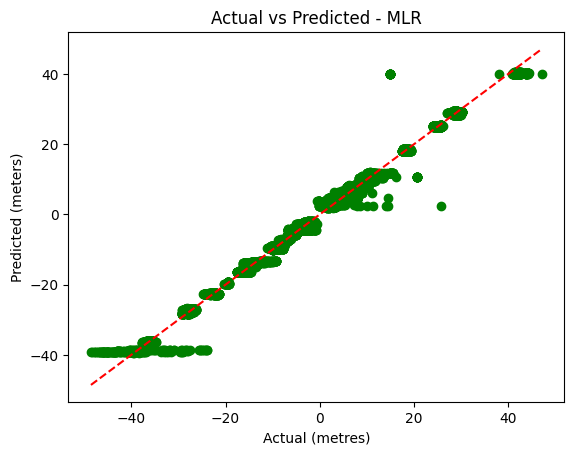

In [124]:
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('Actual (metres)')
plt.ylabel('Predicted (meters)')
plt.title('Actual vs Predicted - MLR')
#plt.grid(True)
plt.show()
